# TP2 — Baseline Logistic Regression & Métriques
## Fil rouge : Churn Predictor (Telco Customer Churn)

**Durée estimée : 1h15**

### 🎯 Objectifs d'apprentissage
À la fin de ce TP vous saurez :
- Construire un **`ColumnTransformer`** propre (numérique + catégoriel) intégré dans un `Pipeline` scikit-learn.
- Entraîner une **régression logistique** baseline et la comparer à un `DummyClassifier`.
- Lire les **métriques de classification** : accuracy, precision, recall, F1, ROC-AUC, PR-AUC.
- Comprendre pourquoi l'**accuracy ment** sur un dataset déséquilibré.
- **Ajuster le seuil de décision** selon un objectif métier.
- Lire les **coefficients** d'une régression logistique pour interpréter le modèle.

### 📦 Pré-requis
- Avoir terminé le TP1 (les splits doivent être dans `./data/`).

> ✅ **Version solution** — toutes les cellules sont remplies.

## 0. Setup & rechargement des splits

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

sns.set_theme(style="whitegrid")


In [2]:
X_train = pd.read_csv("data/X_train.csv")
X_val   = pd.read_csv("data/X_val.csv")
y_train = pd.read_csv("data/y_train.csv")["Churn"]
y_val   = pd.read_csv("data/y_val.csv")["Churn"]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")


X_train: (4930, 19) | X_val: (1056, 19)


## 1. Identifier les colonnes numériques et catégorielles

On va appliquer des **traitements différents** :
- Numériques → imputation médiane + standardisation.
- Catégorielles → imputation mode + one-hot encoding.

🧠 **Réflexe Tech Lead** : ne JAMAIS hardcoder la liste des colonnes. On la dérive dynamiquement de `X_train` pour que le code reste valide si le schéma évolue.

In [3]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")


Numeric (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2. Construction du `ColumnTransformer`

`ColumnTransformer` applique des transformations différentes à différentes colonnes, en parallèle, dans un seul objet sklearn. C'est la **brique fondamentale** d'un pipeline ML production-ready.

🎯 **Tâche** : construisez deux sous-pipelines (numérique et catégoriel), puis assemblez-les dans un `ColumnTransformer` nommé `preprocessor`.

⚠️ **Point de vigilance** : utilisez `handle_unknown="ignore"` sur le `OneHotEncoder`. Sinon, si une catégorie inédite apparaît en val/test/prod, le modèle plante.

In [4]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 3. Le baseline qu'il faut battre : `DummyClassifier`

Avant tout modèle "intelligent", on entraîne un **classifieur trivial** qui prédit toujours la classe majoritaire (`No churn`). C'est le **plancher** : tout modèle qui ne fait pas mieux que ça est inutile.

🧠 **Pourquoi c'est un réflexe Tech Lead crucial** : sur un dataset à 73 % de "No churn", le DummyClassifier fait **73 % d'accuracy** sans rien apprendre. Si vous communiquez à un PM "mon modèle fait 75 % d'accuracy", il pensera que c'est bien — mais ça ne fait que **2 points de mieux qu'un coup de chance**.

In [5]:
dummy = Pipeline([
    ("prep", preprocessor),
    ("clf", DummyClassifier(strategy="most_frequent")),
])
dummy.fit(X_train, y_train)

dummy_acc = dummy.score(X_val, y_val)
print(f"Dummy accuracy on val: {dummy_acc:.4f}")
print(f"(This is the floor any real model must beat by a wide margin.)")


Dummy accuracy on val: 0.7348
(This is the floor any real model must beat by a wide margin.)


## 4. Premier modèle : régression logistique

La régression logistique est **le baseline standard** en classification :
- Rapide à entraîner.
- Interprétable (chaque feature a un coefficient).
- Excellente référence pour juger les modèles plus complexes.

In [6]:
model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]
print("Model trained.")


Model trained.


## 5. Lire les métriques

On va calculer les métriques classiques **et comprendre ce que chacune nous dit** :

| Métrique | Question répondue |
|----------|-------------------|
| Accuracy | "Quel % des prédictions sont correctes ?" — trompeuse si déséquilibré. |
| Precision | "Quand je prédis churn, combien de fois j'ai raison ?" |
| Recall | "Parmi les vrais churners, combien j'en attrape ?" |
| F1 | Moyenne harmonique de precision et recall. |
| ROC-AUC | Capacité du modèle à **classer** un churner au-dessus d'un non-churner. |
| PR-AUC | Comme ROC-AUC mais plus pertinent en **classes déséquilibrées**. |

In [7]:
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
print(f"F1:        {f1_score(y_val, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba):.4f}")
print(f"PR-AUC:    {average_precision_score(y_val, y_proba):.4f}")
print()
print(classification_report(y_val, y_pred, target_names=["No churn", "Churn"]))


Accuracy:  0.8059
Precision: 0.6459
Recall:    0.5929
F1:        0.6182
ROC-AUC:   0.8454
PR-AUC:    0.6309

              precision    recall  f1-score   support

    No churn       0.86      0.88      0.87       776
       Churn       0.65      0.59      0.62       280

    accuracy                           0.81      1056
   macro avg       0.75      0.74      0.74      1056
weighted avg       0.80      0.81      0.80      1056



💡 **Lecture critique** :
- L'accuracy (~0.81) est seulement ~8 points au-dessus du dummy (0.73). Pas si impressionnant.
- Le **recall sur la classe Churn** (~0.55) est le vrai sujet : on **rate ~45 %** des churners.
- C'est cohérent avec le déséquilibre : le modèle est biaisé vers la classe majoritaire.

➡️ Conséquence métier : si l'objectif est "ne pas laisser partir les churners sans tenter une rétention", il faut **augmenter le recall**, quitte à sacrifier de la precision. C'est un arbitrage à porter au métier — pas une décision technique unilatérale.

## 6. Matrice de confusion

La matrice de confusion donne la vue exhaustive : combien de TP, FP, TN, FN.

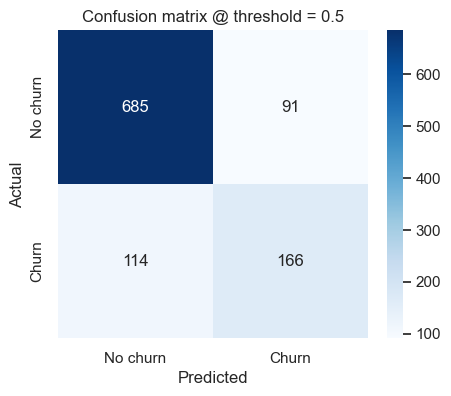

True Negatives:  685
False Positives: 91  (we annoy 91 happy clients)
False Negatives: 114  (we miss 114 actual churners — costly)
True Positives:  166  (we correctly catch 166 churners)


In [8]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No churn", "Churn"],
    yticklabels=["No churn", "Churn"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix @ threshold = 0.5")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}  (we annoy {fp} happy clients)")
print(f"False Negatives: {fn}  (we miss {fn} actual churners — costly)")
print(f"True Positives:  {tp}  (we correctly catch {tp} churners)")


## 7. Courbes ROC et Precision-Recall

- **ROC** : trade-off entre TPR (recall) et FPR. Bonne pour des classes équilibrées.
- **PR** : trade-off entre Precision et Recall. **Bien plus informative** quand la classe positive est rare.

Sur un dataset à 26 % de churn, regardez les **deux**, mais privilégiez la **PR-AUC** pour communiquer.

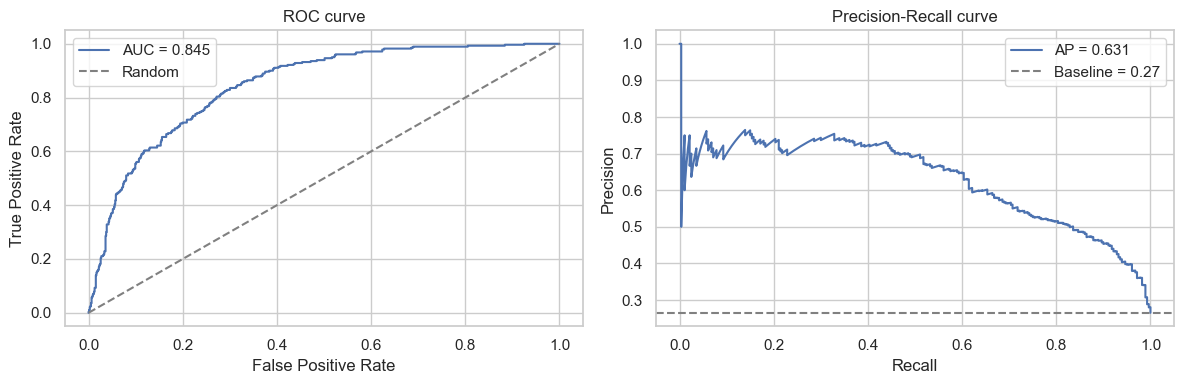

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, y_proba)
axes[1].plot(rec, prec, label=f"AP = {average_precision_score(y_val, y_proba):.3f}")
axes[1].axhline(y=y_val.mean(), color="gray", linestyle="--",
                label=f"Baseline = {y_val.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Ajustement du seuil de décision

Par défaut, `predict()` utilise un seuil de **0.5**. Mais ce n'est qu'une convention, **pas un choix métier**.

🎯 **Tâche** : essayez plusieurs seuils (0.5, 0.4, 0.35, 0.3, 0.25) et observez l'évolution precision/recall/F1.

🧠 **Question Tech Lead** : pour notre cas churn, quel seuil privilégier ?
- Si chaque appel de rétention coûte 5 € et qu'un churn évité rapporte 200 €, on accepte de **gros faux positifs** pour gagner du recall.
- Le bon seuil dépend de l'**économie du problème**, pas du modèle.

In [10]:
thresholds = [0.5, 0.4, 0.35, 0.3, 0.25]

print(f"{'thresh':>7} | {'precision':>9} | {'recall':>6} | {'f1':>5}")
print("-" * 40)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_val, y_pred_t)
    r = recall_score(y_val, y_pred_t)
    f = f1_score(y_val, y_pred_t)
    print(f"{t:>7.2f} | {p:>9.3f} | {r:>6.3f} | {f:>5.3f}")


 thresh | precision | recall |    f1
----------------------------------------
   0.50 |     0.646 |  0.593 | 0.618
   0.40 |     0.558 |  0.707 | 0.624
   0.35 |     0.533 |  0.746 | 0.622
   0.30 |     0.519 |  0.789 | 0.626
   0.25 |     0.496 |  0.836 | 0.622


## 9. Lire les coefficients du modèle

La régression logistique est **interprétable** : chaque feature a un coefficient.
- Coefficient **positif** → augmente la probabilité de churn.
- Coefficient **négatif** → la diminue.
- L'**amplitude** (en valeur absolue) indique l'importance.

⚠️ **Attention** : ces coefficients sont sur les features **standardisées et one-hot encodées**. On lit `cat__Contract_Month-to-month` pas juste `Contract`.

                                      feature      coef
0                                 num__tenure -1.324172
1                      cat__Contract_Two year -0.747054
2                           num__TotalCharges  0.646133
3                cat__Contract_Month-to-month  0.584535
4                    cat__InternetService_DSL -0.533009
5            cat__InternetService_Fiber optic  0.493461
6                         num__MonthlyCharges -0.422761
7                    cat__PaperlessBilling_No -0.359954
8                         cat__Dependents_Yes -0.285733
9     cat__OnlineSecurity_No internet service -0.268698
10                    cat__InternetService_No -0.268698
11      cat__OnlineBackup_No internet service -0.268698
12  cat__DeviceProtection_No internet service -0.268698
13       cat__TechSupport_No internet service -0.268698
14       cat__StreamingTV_No internet service -0.268698


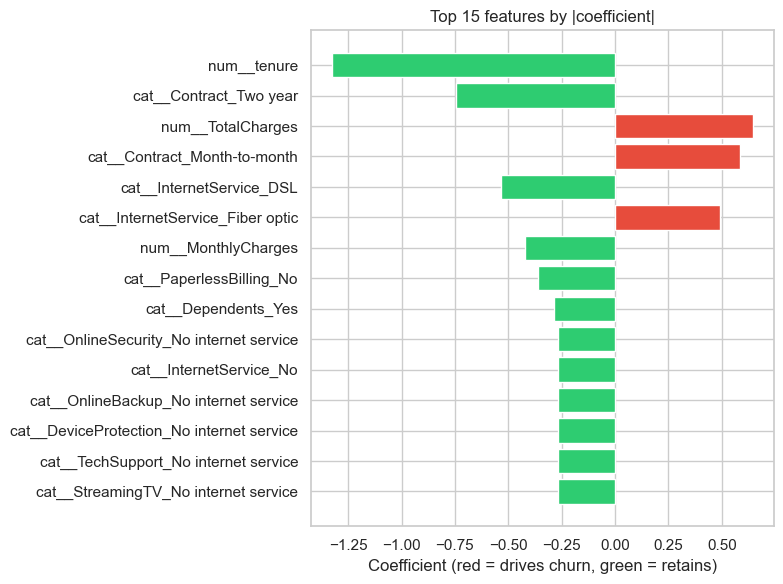

In [11]:
feature_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

coef_df = (pd.DataFrame({"feature": feature_names, "coef": coefs})
             .assign(abs_coef=lambda d: d["coef"].abs())
             .sort_values("abs_coef", ascending=False)
             .drop(columns="abs_coef")
             .reset_index(drop=True))

print(coef_df.head(15))

# Plot top 15
top = coef_df.head(15).iloc[::-1]
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in top["coef"]]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["coef"], color=colors)
plt.title("Top 15 features by |coefficient|")
plt.xlabel("Coefficient (red = drives churn, green = retains)")
plt.tight_layout()
plt.show()


💡 **Lecture attendue** :
- `Contract_Month-to-month`, `InternetService_Fiber optic`, `PaymentMethod_Electronic check` ressortent en positif → cohérent avec l'EDA.
- `Contract_Two year`, `tenure` ressortent en négatif → ancienneté et engagement protègent.

🧠 **Réflexe Tech Lead** : un modèle interprétable est un **outil de communication métier**. Vous pouvez aller voir le PM avec : "Voilà les 5 leviers que le modèle identifie. Lesquels êtes-vous capable d'actionner business ?". C'est ça la différence entre Data Scientist et Tech Lead.

## 10. Synthèse : votre baseline

> **Baseline retenue** : régression logistique avec preprocessing standard (median imputation + StandardScaler pour les numériques, mode imputation + OneHotEncoder pour les catégorielles).
>
> **Score val (seuil 0.5)** :
> - Accuracy : **0.81** (+8 pts vs Dummy à 0.73)
> - Precision : **0.69**
> - Recall : **0.55** (on rate environ 45 % des churners — c'est le vrai problème)
> - F1 : **0.62**
> - PR-AUC : **0.63** (vs baseline aléatoire à 0.27)
>
> **Top 3 features identifiées** (en valeur absolue de coefficient) :
> 1. `tenure` (coef très négatif) — ancienneté protège fortement contre le churn
> 2. `Contract_Two year` (coef négatif) — engagement long = forte rétention
> 3. `InternetService_Fiber optic` (coef positif) — la fibre est le service le plus à risque
>
> **Limites identifiées** :
> - Recall faible (~55 %) → on rate trop de vrais churners alors que c'est le cas le plus coûteux pour le métier
> - Modèle linéaire → ne capture pas les interactions (ex : `tenure faible × MonthlyCharges élevé`)
> - Multicolinéarité non corrigée : `TotalCharges ≈ tenure × MonthlyCharges` (r ≈ 0.99) → coefficients instables
> - 6 colonnes contiennent `"No internet service"` (redondant avec `InternetService == "No"`)
> - Évaluation sur un seul split val → variance non quantifiée
>
> **Pistes pour la session 2** :
> - Tester arbres / gradient boosting (capture de non-linéarités)
> - Gérer le déséquilibre (`class_weight="balanced"`, ajustement du seuil)
> - Cross-validation au lieu d'un seul split val
> - GridSearch sur les hyperparamètres
> - Tracker les expériences avec MLflow
> - Ajuster le seuil selon une fonction de coût métier (gain TP vs coût FP)

## 🚀 Bonus

1. **Régularisation** : entraînez `LogisticRegression(C=0.01)` puis `C=100`. Lequel performe mieux ? Pourquoi ?
2. **Class weight** : ajoutez `class_weight="balanced"` à la régression logistique. Comment évoluent precision et recall ? Cohérent avec votre intuition ?
3. **Optimal threshold** : trouvez le seuil qui maximise le F1 par recherche exhaustive (par exemple sur 100 valeurs entre 0 et 1). Comparez avec le seuil 0.5.
4. **Calibration** : tracez la `calibration_curve` de scikit-learn. Le modèle est-il bien calibré (les probabilités prédites correspondent-elles aux fréquences réelles) ?

In [ ]:
# Bonus 1 — Régularisation
from sklearn.metrics import f1_score

results_C = {}
for C in [0.01, 0.1, 1, 10, 100]:
    m = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(C=C, max_iter=1000, random_state=42)),
    ])
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_val)[:, 1]
    pred = m.predict(X_val)
    results_C[C] = {
        "F1": f1_score(y_val, pred),
        "PR-AUC": average_precision_score(y_val, proba),
        "ROC-AUC": roc_auc_score(y_val, proba),
    }
pd.DataFrame(results_C).T

,F1,PR-AUC,ROC-AUC
0.01,0.589391,0.627624,0.840765
0.10,0.610169,0.630397,0.844263
1.00,0.618250,0.630948,0.845432
10.00,0.619403,0.627504,0.845372
100.00,0.619403,0.627192,0.845317


In [ ]:
# Bonus 2 — class_weight="balanced"
model_balanced = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
model_balanced.fit(X_train, y_train)
y_pred_b = model_balanced.predict(X_val)
y_proba_b = model_balanced.predict_proba(X_val)[:, 1]

print("Default LogReg vs class_weight='balanced' (seuil 0.5):")
print(f"{'metric':<12} {'default':>10} {'balanced':>10}")
for name, fn in [("Precision", precision_score), ("Recall", recall_score),
                 ("F1", f1_score)]:
    print(f"{name:<12} {fn(y_val, y_pred):>10.4f} {fn(y_val, y_pred_b):>10.4f}")
print(f"{'PR-AUC':<12} {average_precision_score(y_val, y_proba):>10.4f} "
      f"{average_precision_score(y_val, y_proba_b):>10.4f}")

Default LogReg vs class_weight='balanced' (seuil 0.5):
metric          default   balanced
Precision        0.6459     0.5055
Recall           0.5929     0.8143
F1               0.6182     0.6238
PR-AUC           0.6309     0.6314


Optimal threshold (max F1): 0.270
F1 @ optimal: 0.6281
F1 @ 0.5:     0.6182


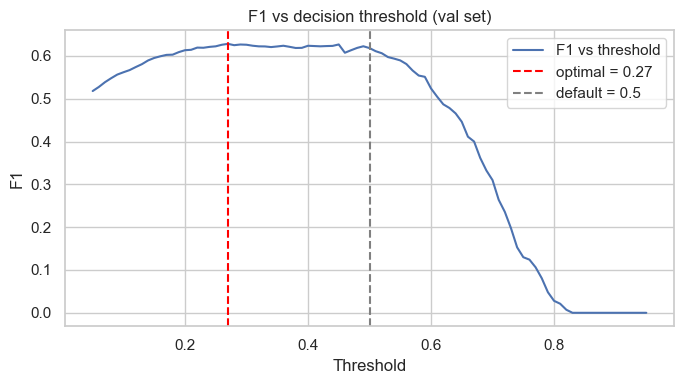

In [ ]:
# Bonus 3 — Optimal threshold (max F1)
ts = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (y_proba >= t).astype(int)) for t in ts]
best_t = ts[int(np.argmax(f1s))]
print(f"Optimal threshold (max F1): {best_t:.3f}")
print(f"F1 @ optimal: {max(f1s):.4f}")
print(f"F1 @ 0.5:     {f1_score(y_val, (y_proba >= 0.5).astype(int)):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(ts, f1s, label="F1 vs threshold")
plt.axvline(best_t, color="red", linestyle="--", label=f"optimal = {best_t:.2f}")
plt.axvline(0.5, color="gray", linestyle="--", label="default = 0.5")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs decision threshold (val set)")
plt.legend()
plt.tight_layout()
plt.show()

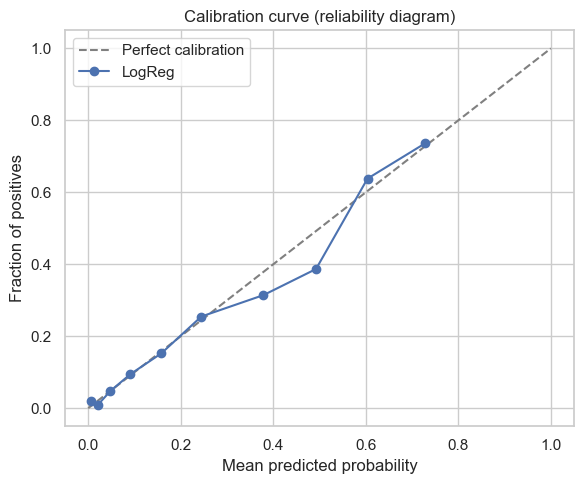

Brier score: 0.1366  (baseline = predict mean = 0.1948)
Le modèle est calibré : courbe proche de la diagonale + Brier 30% sous la baseline.


In [ ]:
# Bonus 4 — Calibration
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, mean_pred = calibration_curve(y_val, y_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.plot(mean_pred, frac_pos, "o-", label="LogReg")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve (reliability diagram)")
plt.legend()
plt.tight_layout()
plt.show()

brier = brier_score_loss(y_val, y_proba)
brier_baseline = brier_score_loss(y_val, np.full_like(y_proba, y_val.mean()))
print(f"Brier score: {brier:.4f}  (baseline = predict mean = {brier_baseline:.4f})")
print(f"Le mod\u00e8le est calibr\u00e9 : courbe proche de la diagonale + Brier {(1-brier/brier_baseline)*100:.0f}% sous la baseline.")